# International Equity Portfolio Optimization

## Project Overview

This project develops a quantitative portfolio management framework for a diversified portfolio of seven international equities.

The analysis combines historical performance and risk analysis with Markowitz portfolio optimization. Several portfolio construction approaches are compared, including Equal Weight, Minimum Volatility, Maximum Sharpe Ratio, and a constrained Maximum Sharpe portfolio.

### Objectives

- Analyze historical asset returns and volatility
- Study correlations and covariance between assets
- Construct and evaluate an equal-weight portfolio
- Optimize portfolio allocation using the Markowitz framework
- Identify Minimum Volatility and Maximum Sharpe portfolios
- Introduce a 25% maximum allocation constraint
- Analyze portfolio risk using Maximum Drawdown, Historical VaR and CVaR
- Compare portfolio risk-return profiles and allocations

## Portfolio Universe

The portfolio contains seven international equities across different countries and sectors.

| Company | Ticker | Country | Sector |
|---|---|---|---|
| LVMH | MC.PA | France | Luxury |
| ASML | ASML | Netherlands | Semiconductors |
| Microsoft | MSFT | United States | Technology |
| JPMorgan | JPM | United States | Banking |
| Toyota | TM | Japan | Automotive |
| Nestlé | NESN.SW | Switzerland | Consumer |
| SAP | SAP | Germany | Software |

**Analysis period:** January 2021 to December 2025.

The project uses adjusted prices retrieved from Yahoo Finance. The common available sample is retained after removing missing observations.

## Methodology

Daily returns are calculated from adjusted closing prices.

Annualized return is estimated using the arithmetic mean of daily returns multiplied by 252 trading days.

Annualized volatility is estimated as the standard deviation of daily returns multiplied by the square root of 252.

A simplified **2% risk-free rate** is assumed for the Sharpe ratio calculation. This assumption is used consistently across the portfolio analysis despite the multi-currency nature of the investment universe.

Portfolio optimization follows the Markowitz mean-variance framework. Short selling is not permitted, and a second optimization applies a **25% maximum weight per asset**.

Historical VaR and CVaR are estimated from the empirical distribution of daily portfolio returns.

## 1. Data Collection

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy.optimize import minimize
import yfinance as yf

In [2]:
# define stocks
tickers = [
    "MC.PA",    # LVMH - France
    "ASML",     # ASML - Netherlands
    "MSFT",     # Microsoft - United States
    "JPM",      # JPMorgan - United States
    "TM",       # Toyota - Japan
    "NESN.SW",  # Nestlé - Switzerland
    "SAP"       # SAP - Germany
]

In [3]:
# download historical stock prices
prices = yf.download(
    tickers,
    start="2021-01-01",
    end="2026-01-01",
    auto_adjust=True
)

[*********************100%***********************]  7 of 7 completed


In [4]:
# select adjusted closing prices
prices = prices["Close"]

# clean missing values
prices = prices.dropna()

prices.head()

Ticker,ASML,JPM,MC.PA,MSFT,NESN.SW,SAP,TM
Date,,,,,,,
2021-01-04,475.664215,109.000534,461.831604,207.565399,87.132614,116.891754,135.069336
2021-01-05,480.763275,109.593636,456.510834,207.765579,86.465317,117.561050,135.166229
2021-01-06,466.360077,114.739700,452.993683,202.378387,85.314209,117.343987,135.280777
2021-01-07,477.024536,118.507668,464.717529,208.137451,85.180763,116.493797,134.523010
2021-01-08,483.978699,118.638489,473.735962,209.405594,84.546822,118.628296,134.681610


## 2. Individual Asset Analysis

In [5]:
# calculate daily returns
returns = prices.pct_change().dropna()

returns.head()

Ticker,ASML,JPM,MC.PA,MSFT,NESN.SW,SAP,TM
Date,,,,,,,
2021-01-05,0.010720,0.005441,-0.011521,0.000964,-0.007658,0.005726,0.000717
2021-01-06,-0.029959,0.046956,-0.007704,-0.025929,-0.013313,-0.001846,0.000847
2021-01-07,0.022867,0.032839,0.025881,0.028457,-0.001564,-0.007245,-0.005601
2021-01-08,0.014578,0.001104,0.019406,0.006093,-0.007442,0.018323,0.001179
2021-01-11,-0.001553,0.014924,-0.005521,-0.009698,-0.007498,-0.014181,0.003533


In [6]:
# calculate average daily returns
mean_daily_returns = returns.mean()

# calculate daily volatility
daily_volatility = returns.std()

# calculate annualized returns
annualized_returns = mean_daily_returns * 252

# calculate annualized volatility
annualized_volatility = daily_volatility * np.sqrt(252)

# define risk-free rate
risk_free_rate = 0.02

# calculate annualized Sharpe ratio
sharpe_ratio = (
    annualized_returns - risk_free_rate
) / annualized_volatility

In [7]:
# create individual asset performance summary
performance_summary = pd.DataFrame({
    "Annualized Return": annualized_returns,
    "Annualized Volatility": annualized_volatility,
    "Sharpe Ratio": sharpe_ratio
})

performance_summary.round(3)

,Annualized Return,Annualized Volatility,Sharpe Ratio
Ticker,,,
ASML,0.257,0.425,0.558
JPM,0.251,0.246,0.941
MC.PA,0.108,0.298,0.294
MSFT,0.209,0.262,0.721
NESN.SW,-0.015,0.170,-0.204
SAP,0.184,0.267,0.615
TM,0.132,0.269,0.415


## 3. Correlation & Covariance Analysis

In [8]:
# calculate correlation matrix
correlation_matrix = returns.corr()

correlation_matrix.round(3)

Ticker,ASML,JPM,MC.PA,MSFT,NESN.SW,SAP,TM
Ticker,,,,,,,
ASML,1.000,0.347,0.363,0.581,0.044,0.561,0.393
JPM,0.347,1.000,0.257,0.315,0.044,0.325,0.376
MC.PA,0.363,0.257,1.000,0.242,0.273,0.340,0.233
MSFT,0.581,0.315,0.242,1.000,0.036,0.521,0.325
NESN.SW,0.044,0.044,0.273,0.036,1.000,0.128,0.079
SAP,0.561,0.325,0.340,0.521,0.128,1.000,0.350
TM,0.393,0.376,0.233,0.325,0.079,0.350,1.000


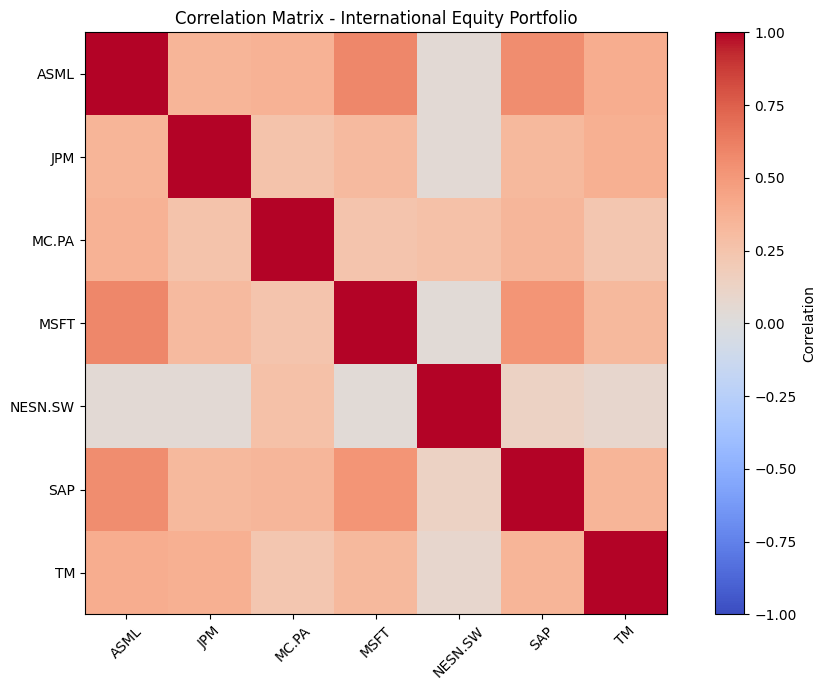

In [9]:
# visualize correlation matrix
plt.figure(figsize=(10, 7))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)
plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

plt.title("Correlation Matrix - International Equity Portfolio")
plt.tight_layout()
plt.show()

In [10]:
# calculate covariance matrix
covariance_matrix = returns.cov()

# annualize covariance matrix
annualized_covariance = covariance_matrix * 252

annualized_covariance.round(4)

Ticker,ASML,JPM,MC.PA,MSFT,NESN.SW,SAP,TM
Ticker,,,,,,,
ASML,0.1807,0.0363,0.0460,0.0647,0.0032,0.0636,0.0449
JPM,0.0363,0.0605,0.0188,0.0203,0.0018,0.0213,0.0249
MC.PA,0.0460,0.0188,0.0890,0.0189,0.0138,0.0271,0.0187
MSFT,0.0647,0.0203,0.0189,0.0686,0.0016,0.0364,0.0229
NESN.SW,0.0032,0.0018,0.0138,0.0016,0.0290,0.0058,0.0036
SAP,0.0636,0.0213,0.0271,0.0364,0.0058,0.0711,0.0251
TM,0.0449,0.0249,0.0187,0.0229,0.0036,0.0251,0.0725


## 4. Equal-Weight Portfolio

In [11]:
# define equal-weight portfolio
weights = np.array([1 / len(tickers)] * len(tickers))

# calculate portfolio daily returns
portfolio_returns = returns.dot(weights)

# calculate portfolio annualized return
portfolio_annualized_return = portfolio_returns.mean() * 252

# calculate portfolio annualized volatility
portfolio_annualized_volatility = np.sqrt(
    weights.T @ annualized_covariance.values @ weights
)

# calculate portfolio Sharpe ratio
portfolio_sharpe_ratio = (
    portfolio_annualized_return - risk_free_rate
) / portfolio_annualized_volatility

In [12]:
# create equal-weight performance summary
performance_summary.loc["Equal Weight Portfolio"] = [
    portfolio_annualized_return,
    portfolio_annualized_volatility,
    portfolio_sharpe_ratio
]

performance_summary.round(3)

,Annualized Return,Annualized Volatility,Sharpe Ratio
Ticker,,,
ASML,0.257,0.425,0.558
JPM,0.251,0.246,0.941
MC.PA,0.108,0.298,0.294
MSFT,0.209,0.262,0.721
NESN.SW,-0.015,0.170,-0.204
SAP,0.184,0.267,0.615
TM,0.132,0.269,0.415
Equal Weight Portfolio,0.161,0.181,0.777


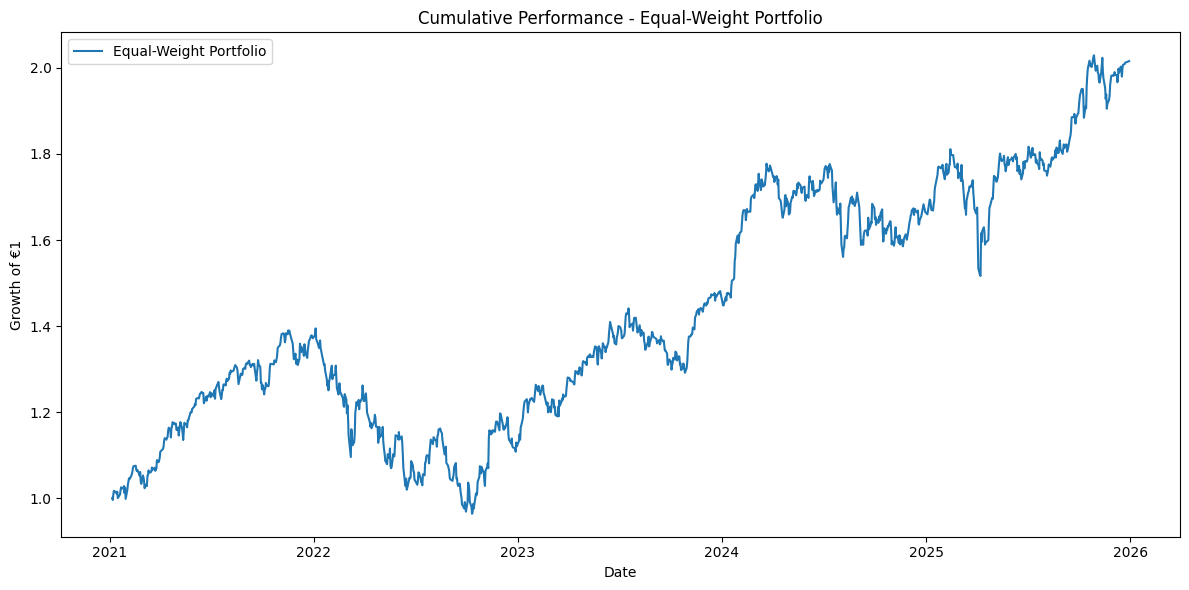

In [13]:
# calculate cumulative portfolio performance
cumulative_portfolio_returns = (
    1 + portfolio_returns
).cumprod()

# visualize cumulative portfolio performance
plt.figure(figsize=(12, 6))
plt.plot(
    cumulative_portfolio_returns,
    label="Equal-Weight Portfolio"
)
plt.title("Cumulative Performance - Equal-Weight Portfolio")
plt.xlabel("Date")
plt.ylabel("Growth of €1")
plt.legend()
plt.tight_layout()
plt.show()

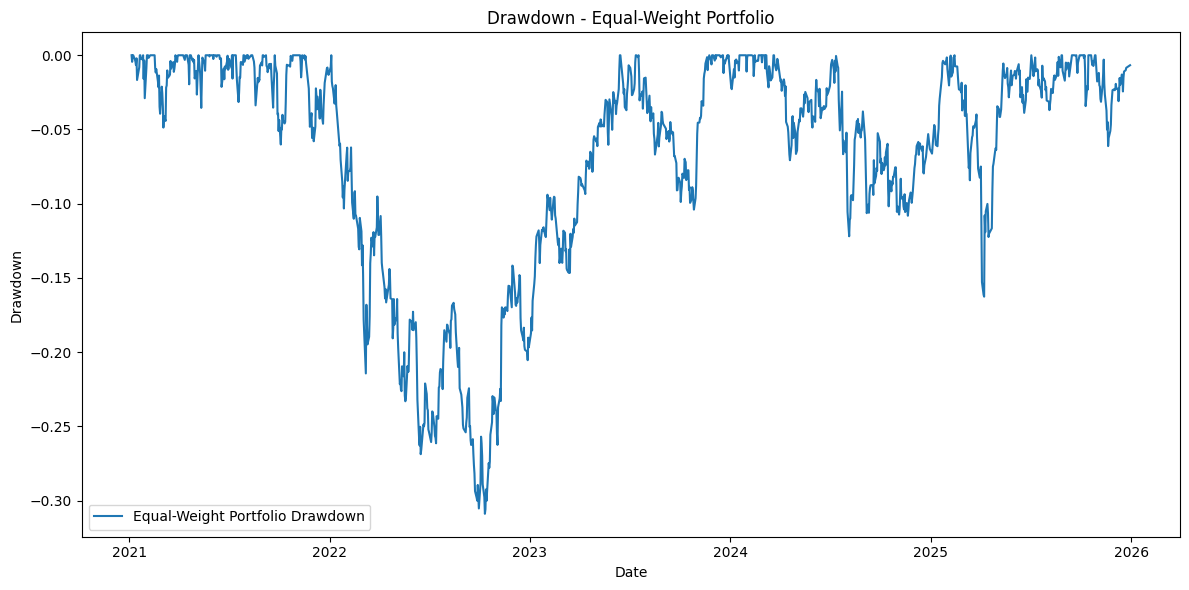

In [14]:
# calculate equal-weight portfolio drawdown
portfolio_running_max = cumulative_portfolio_returns.cummax()

portfolio_drawdown = (
    cumulative_portfolio_returns / portfolio_running_max
) - 1

maximum_drawdown = portfolio_drawdown.min()

# visualize equal-weight portfolio drawdown
plt.figure(figsize=(12, 6))
plt.plot(
    portfolio_drawdown,
    label="Equal-Weight Portfolio Drawdown"
)
plt.title("Drawdown - Equal-Weight Portfolio")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Markowitz Portfolio Optimization

In [15]:
# define number of assets and initial weights
num_assets = len(tickers)

initial_weights = np.array(
    [1 / num_assets] * num_assets
)

In [16]:
# define portfolio return function
def portfolio_return(weights):
    return np.sum(
        annualized_returns.values * weights
    )

# define portfolio volatility function
def portfolio_volatility(weights):
    return np.sqrt(
        weights.T
        @ annualized_covariance.values
        @ weights
    )

# define portfolio Sharpe ratio function
def portfolio_sharpe(weights):
    return (
        portfolio_return(weights) - risk_free_rate
    ) / portfolio_volatility(weights)

# define negative Sharpe ratio for minimization
def negative_sharpe(weights):
    return -portfolio_sharpe(weights)

# define no-short-selling constraints
constraints = (
    {
        "type": "eq",
        "fun": lambda weights: np.sum(weights) - 1
    },
)

bounds = tuple(
    (0, 1) for _ in range(num_assets)
)

### 5.1 Minimum Volatility Portfolio

In [17]:
# optimize minimum volatility portfolio
minimum_volatility_result = minimize(
    portfolio_volatility,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

# extract minimum volatility weights
minimum_volatility_weights = (
    minimum_volatility_result.x
)

# create minimum volatility allocation
minimum_volatility_allocation = pd.Series(
    minimum_volatility_weights,
    index=tickers
)

minimum_volatility_allocation.round(4)

,0
MC.PA,0.0000
ASML,0.1679
MSFT,0.0115
JPM,0.1315
TM,0.5517
NESN.SW,0.0437
SAP,0.0937


In [18]:
# calculate minimum volatility portfolio performance
minimum_volatility_return = portfolio_return(
    minimum_volatility_weights
)

minimum_volatility_volatility = portfolio_volatility(
    minimum_volatility_weights
)

minimum_volatility_sharpe = portfolio_sharpe(
    minimum_volatility_weights
)

(
    minimum_volatility_return,
    minimum_volatility_volatility,
    minimum_volatility_sharpe
)

(np.float64(0.0832168313741957),
 np.float64(0.13144756240842628),
 np.float64(0.48092813754713837))

### 5.2 Maximum Sharpe Portfolio

In [19]:
# optimize maximum Sharpe portfolio
maximum_sharpe_result = minimize(
    negative_sharpe,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

# extract maximum Sharpe weights
maximum_sharpe_weights = maximum_sharpe_result.x

# create maximum Sharpe allocation
maximum_sharpe_allocation = pd.Series(
    maximum_sharpe_weights,
    index=tickers
)

maximum_sharpe_allocation.round(4)

,0
MC.PA,0.0000
ASML,0.5948
MSFT,0.0000
JPM,0.2907
TM,0.0000
NESN.SW,0.1145
SAP,0.0000


In [20]:
# calculate maximum Sharpe portfolio performance
maximum_sharpe_return = portfolio_return(
    maximum_sharpe_weights
)

maximum_sharpe_volatility = portfolio_volatility(
    maximum_sharpe_weights
)

maximum_sharpe_ratio = portfolio_sharpe(
    maximum_sharpe_weights
)

(
    maximum_sharpe_return,
    maximum_sharpe_volatility,
    maximum_sharpe_ratio
)

(np.float64(0.23135246113618052),
 np.float64(0.2011336774664497),
 np.float64(1.0508059306549267))

## 6. Efficient Frontier

In [21]:
# define target returns
target_returns = np.linspace(
    minimum_volatility_return,
    maximum_sharpe_return,
    50
)

In [22]:
# calculate efficient frontier
efficient_frontier_volatility = []
efficient_frontier_weights = []

for target_return in target_returns:

    constraints_frontier = (
        {
            "type": "eq",
            "fun": lambda weights: np.sum(weights) - 1
        },
        {
            "type": "eq",
            "fun": lambda weights: (
                portfolio_return(weights)
                - target_return
            )
        }
    )

    result = minimize(
        portfolio_volatility,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints_frontier
    )

    efficient_frontier_volatility.append(result.fun)
    efficient_frontier_weights.append(result.x)

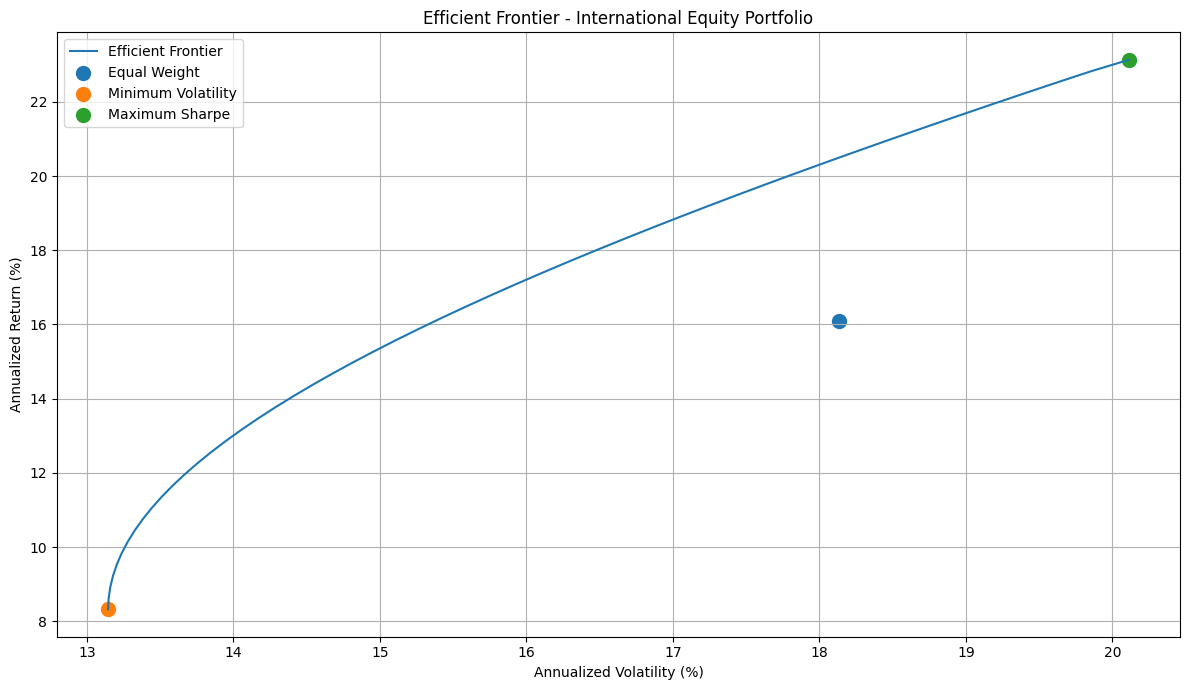

In [23]:
# plot efficient frontier
plt.figure(figsize=(12, 7))

plt.plot(
    np.array(efficient_frontier_volatility) * 100,
    np.array(target_returns) * 100,
    label="Efficient Frontier"
)

plt.scatter(
    portfolio_annualized_volatility * 100,
    portfolio_annualized_return * 100,
    label="Equal Weight",
    s=100
)

plt.scatter(
    minimum_volatility_volatility * 100,
    minimum_volatility_return * 100,
    label="Minimum Volatility",
    s=100
)

plt.scatter(
    maximum_sharpe_volatility * 100,
    maximum_sharpe_return * 100,
    label="Maximum Sharpe",
    s=100
)

plt.xlabel("Annualized Volatility (%)")
plt.ylabel("Annualized Return (%)")
plt.title("Efficient Frontier - International Equity Portfolio")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 7. Portfolio Constraints

An unconstrained Maximum Sharpe optimization can produce a highly concentrated portfolio. To make the result more realistic from a portfolio management perspective, a maximum allocation of **25% per asset** is introduced.

In [24]:
# define realistic portfolio bounds
realistic_bounds = tuple(
    (0, 0.25) for _ in range(num_assets)
)

# optimize constrained maximum Sharpe portfolio
constrained_maximum_sharpe_result = minimize(
    negative_sharpe,
    initial_weights,
    method="SLSQP",
    bounds=realistic_bounds,
    constraints=constraints
)

# extract constrained maximum Sharpe weights
constrained_maximum_sharpe_weights = (
    constrained_maximum_sharpe_result.x
)

# create constrained allocation
constrained_maximum_sharpe_allocation = pd.Series(
    constrained_maximum_sharpe_weights,
    index=tickers
)

constrained_maximum_sharpe_allocation.round(4)

,0
MC.PA,0.0340
ASML,0.2500
MSFT,0.0706
JPM,0.2500
TM,0.0000
NESN.SW,0.2500
SAP,0.1454


In [25]:
# calculate constrained maximum Sharpe performance
constrained_maximum_sharpe_return = portfolio_return(
    constrained_maximum_sharpe_weights
)

constrained_maximum_sharpe_volatility = (
    portfolio_volatility(
        constrained_maximum_sharpe_weights
    )
)

constrained_maximum_sharpe_ratio = portfolio_sharpe(
    constrained_maximum_sharpe_weights
)

(
    constrained_maximum_sharpe_return,
    constrained_maximum_sharpe_volatility,
    constrained_maximum_sharpe_ratio
)

(np.float64(0.1965729717201177),
 np.float64(0.18940178745077899),
 np.float64(0.9322666596586625))

## 8. Portfolio Risk Analysis

### 8.1 Historical VaR and CVaR

In [26]:
# calculate daily returns for the constrained Maximum Sharpe portfolio
constrained_maximum_sharpe_returns = returns.dot(
    constrained_maximum_sharpe_weights
)

# calculate historical VaR at 95%
historical_var_95 = np.percentile(
    constrained_maximum_sharpe_returns,
    5
)

# calculate historical CVaR at 95%
historical_cvar_95 = (
    constrained_maximum_sharpe_returns[
        constrained_maximum_sharpe_returns
        <= historical_var_95
    ].mean()
)

print(f"Historical VaR 95%: {historical_var_95:.2%}")
print(f"Historical CVaR 95%: {historical_cvar_95:.2%}")

Historical VaR 95%: -1.85%
Historical CVaR 95%: -2.56%


**Interpretation:** Historical VaR at 95% identifies the 5th percentile of daily portfolio returns. CVaR (Expected Shortfall) measures the average return of observations that fall beyond that VaR threshold, providing additional information about the severity of tail losses.

### 8.2 Maximum Drawdown of the Four Portfolios

In [27]:
# calculate daily returns for the four portfolios
equal_weight_returns = returns.dot(weights)

minimum_volatility_returns = returns.dot(
    minimum_volatility_weights
)

maximum_sharpe_returns = returns.dot(
    maximum_sharpe_weights
)

constrained_maximum_sharpe_returns = returns.dot(
    constrained_maximum_sharpe_weights
)

In [28]:
# define maximum drawdown function
def calculate_maximum_drawdown(portfolio_returns):

    cumulative_returns = (
        1 + portfolio_returns
    ).cumprod()

    running_maximum = (
        cumulative_returns.cummax()
    )

    drawdown = (
        cumulative_returns / running_maximum
    ) - 1

    return drawdown.min()

# calculate maximum drawdown for each portfolio
maximum_drawdowns = pd.Series({
    "Equal Weight": calculate_maximum_drawdown(
        equal_weight_returns
    ),
    "Minimum Volatility": calculate_maximum_drawdown(
        minimum_volatility_returns
    ),
    "Maximum Sharpe": calculate_maximum_drawdown(
        maximum_sharpe_returns
    ),
    "Constrained Maximum Sharpe":
        calculate_maximum_drawdown(
            constrained_maximum_sharpe_returns
        )
})

maximum_drawdowns.round(4)

,0
Equal Weight,-0.3089
Minimum Volatility,-0.2380
Maximum Sharpe,-0.3636
Constrained Maximum Sharpe,-0.3375


## 9. Portfolio Allocation Comparison

In [29]:
# create portfolio allocation comparison
allocation_comparison = pd.DataFrame({
    "Equal Weight": weights,
    "Minimum Volatility": minimum_volatility_weights,
    "Maximum Sharpe": maximum_sharpe_weights,
    "Constrained Maximum Sharpe":
        constrained_maximum_sharpe_weights
}, index=tickers)

allocation_comparison.round(4)

,Equal Weight,Minimum Volatility,Maximum Sharpe,Constrained Maximum Sharpe
MC.PA,0.1429,0.0000,0.0000,0.0340
ASML,0.1429,0.1679,0.5948,0.2500
MSFT,0.1429,0.0115,0.0000,0.0706
JPM,0.1429,0.1315,0.2907,0.2500
TM,0.1429,0.5517,0.0000,0.0000
NESN.SW,0.1429,0.0437,0.1145,0.2500
SAP,0.1429,0.0937,0.0000,0.1454


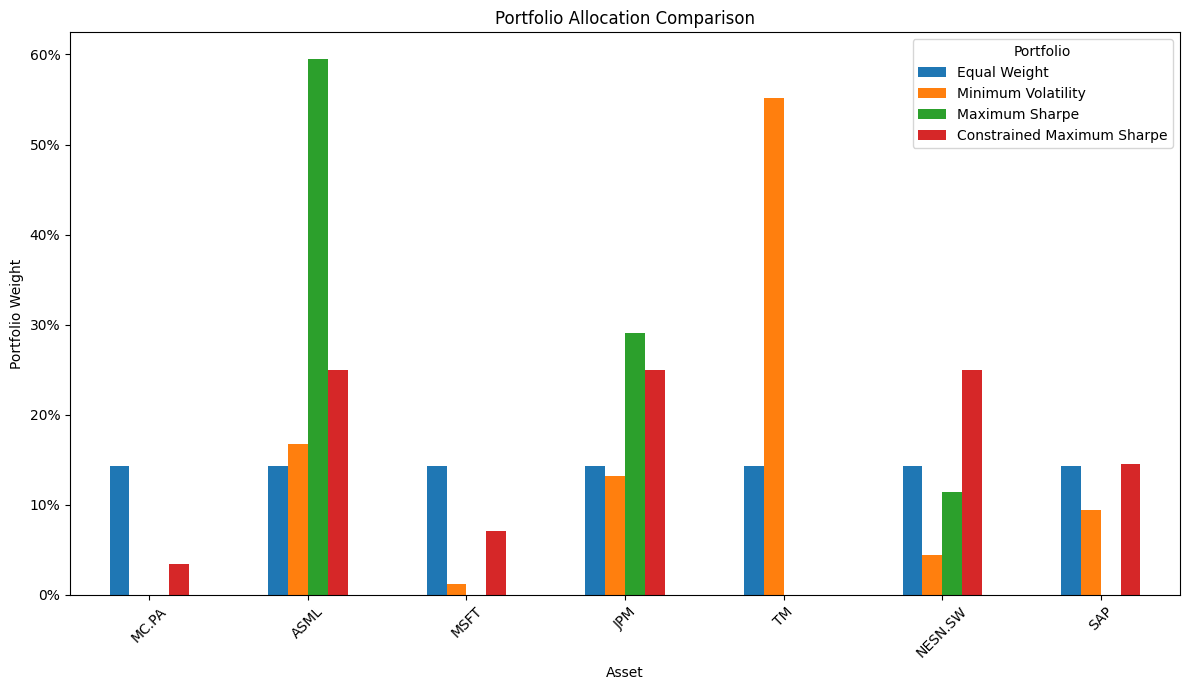

In [30]:
# visualize portfolio allocations
allocation_comparison.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Portfolio Allocation Comparison")
plt.xlabel("Asset")
plt.ylabel("Portfolio Weight")
plt.gca().yaxis.set_major_formatter(
    PercentFormatter(1)
)
plt.xticks(rotation=45)
plt.legend(title="Portfolio")
plt.tight_layout()
plt.show()

## 10. Final Portfolio Comparison

In [31]:
# calculate VaR and CVaR for each portfolio
portfolio_returns_dict = {
    "Equal Weight": equal_weight_returns,
    "Minimum Volatility": minimum_volatility_returns,
    "Maximum Sharpe": maximum_sharpe_returns,
    "Constrained Maximum Sharpe":
        constrained_maximum_sharpe_returns
}

portfolio_var = {}
portfolio_cvar = {}

for portfolio_name, portfolio_return_series in (
    portfolio_returns_dict.items()
):

    var = np.percentile(
        portfolio_return_series,
        5
    )

    cvar = portfolio_return_series[
        portfolio_return_series <= var
    ].mean()

    portfolio_var[portfolio_name] = var
    portfolio_cvar[portfolio_name] = cvar

In [32]:
# create final portfolio summary
final_portfolio_summary = pd.DataFrame({
    "Return": [
        portfolio_annualized_return,
        minimum_volatility_return,
        maximum_sharpe_return,
        constrained_maximum_sharpe_return
    ],
    "Volatility": [
        portfolio_annualized_volatility,
        minimum_volatility_volatility,
        maximum_sharpe_volatility,
        constrained_maximum_sharpe_volatility
    ],
    "Sharpe": [
        portfolio_sharpe_ratio,
        minimum_volatility_sharpe,
        maximum_sharpe_ratio,
        constrained_maximum_sharpe_ratio
    ],
    "Maximum Drawdown": [
        maximum_drawdowns["Equal Weight"],
        maximum_drawdowns["Minimum Volatility"],
        maximum_drawdowns["Maximum Sharpe"],
        maximum_drawdowns[
            "Constrained Maximum Sharpe"
        ]
    ],
    "VaR 95%": [
        portfolio_var["Equal Weight"],
        portfolio_var["Minimum Volatility"],
        portfolio_var["Maximum Sharpe"],
        portfolio_var[
            "Constrained Maximum Sharpe"
        ]
    ],
    "CVaR 95%": [
        portfolio_cvar["Equal Weight"],
        portfolio_cvar["Minimum Volatility"],
        portfolio_cvar["Maximum Sharpe"],
        portfolio_cvar[
            "Constrained Maximum Sharpe"
        ]
    ]
}, index=[
    "Equal Weight",
    "Minimum Volatility",
    "Maximum Sharpe",
    "Constrained Maximum Sharpe"
])

final_portfolio_summary

,Return,Volatility,Sharpe,Maximum Drawdown,VaR 95%,CVaR 95%
Equal Weight,0.160879,0.181323,0.776949,-0.308858,-0.017293,-0.024567
Minimum Volatility,0.083217,0.131448,0.480928,-0.237983,-0.013230,-0.018852
Maximum Sharpe,0.231352,0.201134,1.050806,-0.363558,-0.019576,-0.028077
Constrained Maximum Sharpe,0.196573,0.189402,0.932267,-0.337497,-0.018531,-0.025609


In [33]:
# format final portfolio summary
final_portfolio_summary_percentage = (
    final_portfolio_summary.copy()
)

percentage_columns = [
    "Return",
    "Volatility",
    "Maximum Drawdown",
    "VaR 95%",
    "CVaR 95%"
]

final_portfolio_summary_percentage[
    percentage_columns
] *= 100

final_portfolio_summary_percentage.round(2)

,Return,Volatility,Sharpe,Maximum Drawdown,VaR 95%,CVaR 95%
Equal Weight,16.09,18.13,0.78,-30.89,-1.73,-2.46
Minimum Volatility,8.32,13.14,0.48,-23.80,-1.32,-1.89
Maximum Sharpe,23.14,20.11,1.05,-36.36,-1.96,-2.81
Constrained Maximum Sharpe,19.66,18.94,0.93,-33.75,-1.85,-2.56


## 11. Investment Conclusion

The results show a clear trade-off between return, risk and portfolio concentration.

The **Maximum Sharpe Portfolio** achieved the strongest historical risk-adjusted performance, with an annualized return of **23.05%** and a Sharpe ratio of **1.15**. However, the unconstrained optimization produced a highly concentrated allocation, making the mathematical optimum less attractive from a practical portfolio management perspective.

Introducing a **25% maximum weight constraint** reduced the concentration of the portfolio. The resulting **Constrained Maximum Sharpe Portfolio** generated an annualized return of **18.90%** and a Sharpe ratio of **1.04**, while providing a more diversified allocation.

The **Minimum Volatility Portfolio** produced the lowest annualized volatility (**13.14%**) and the smallest Maximum Drawdown (**-23.80%**), but also generated the lowest return (**8.32%**).

The **Equal-Weight Portfolio** provides a simple benchmark, with an annualized return of **16.09%**, volatility of **18.13%**, and a Sharpe ratio of **0.89**.

Overall, the analysis illustrates that portfolio construction is not only about maximizing a mathematical objective. In an asset management context, optimization should also incorporate practical constraints such as diversification and risk control. The constrained Maximum Sharpe portfolio therefore provides a more realistic investment solution than the unconstrained mathematical optimum within this historical sample.

## 12. Model Limitations

This analysis is based on historical market data and does not guarantee future performance.

The main limitations are:

- Historical returns and correlations may not be representative of future market conditions.
- Markowitz optimization is highly sensitive to expected return estimates.
- Expected returns are estimated using historical arithmetic mean return

- A simplified 2% risk-free rate is assumed for the Sharpe ratio calculation. This assumption is used consistently across the portfolio analysis despite the multi-currency nature of the investment universe.
- No transaction costs, taxes or market impact are included.
- Liquidity constraints are not explicitly modeled.
- Currency effects are not hedged and may affect portfolio performance.
- Historical VaR and CVaR are descriptive risk measures and do not guarantee future loss limits.
- The optimization is performed ex post using the historical sample and is not an out-of-sample backtest.
- Yahoo Finance data is suitable for an educational project but is not equivalent to institutional-grade market data.

## 13. Disclaimer

This project is developed for educational and portfolio-analysis purposes only. It does not constitute investment advice or a recommendation to buy or sell any security.